# Laboratorio del capítulo 3: sistemas de ecuaciones lineales

**Curso:** Métodos Numéricos — Facultad de Economía, Universidad del Pacífico  
**Periodo:** 2026-2  
**Duración sugerida:** dos sesiones de 110 minutos más trabajo autónomo  
**Herramientas:** Python 3 y NumPy

Este laboratorio integra las unidades 3A–3D:

1. sustitución y eliminación de Gauss;
2. factorizaciones LU y Cholesky, y sistemas tridiagonales;
3. sensibilidad y condicionamiento;
4. factorización QR mediante Householder y Givens;
5. Jacobi, Gauss–Seidel y SOR;
6. aplicaciones económicas a mínimos cuadrados y al modelo de Leontief.

Las implementaciones principales se construyen explícitamente. Las rutinas de
NumPy se usan después como referencia y verificación.

## 0. Preparación, objetivos y protocolo numérico

Al terminar, el estudiante debe poder:

- seleccionar un método según estructura, tamaño y precisión requerida;
- distinguir error hacia adelante, residuo y condicionamiento;
- reutilizar una factorización para varios lados derechos;
- verificar una factorización mediante normas relativas;
- interpretar la convergencia de un método estacionario;
- documentar tolerancia, iteraciones y razón de salida.

Ejecute las celdas en orden. Las comprobaciones automáticas forman parte de la
verificación.

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=110)
print("NumPy:", np.__version__)

Matplotlib is building the font cache; this may take a moment.


NumPy: 2.5.2


In [2]:
def norma_relativa_residuo(A, x, b):
    # Calcula ||b-Ax||/(||A||||x||+||b||).
    numerador = np.linalg.norm(b - A @ x)
    denominador = np.linalg.norm(A) * np.linalg.norm(x) + np.linalg.norm(b)
    return numerador / denominador if denominador else numerador

def error_relativo(x, x_ref):
    denominador = np.linalg.norm(x_ref)
    return np.linalg.norm(x - x_ref) / denominador if denominador else np.linalg.norm(x - x_ref)

def verificar_factorizacion(A, producto):
    return np.linalg.norm(A - producto) / np.linalg.norm(A)

## 1. Sistemas triangulares: el núcleo de las factorizaciones

Las factorizaciones reducen un problema general a sistemas triangulares.
Implementaremos sustitución hacia adelante y hacia atrás sin formar inversas.

In [3]:
def sustitucion_adelante(L, b, diagonal_unidad=False):
    L = np.asarray(L, dtype=float)
    b = np.asarray(b, dtype=float)
    n = L.shape[0]
    if L.shape != (n, n) or b.shape != (n,):
        raise ValueError("Dimensiones incompatibles")
    y = np.zeros(n)
    for i in range(n):
        rhs = b[i] - L[i, :i] @ y[:i]
        pivote = 1.0 if diagonal_unidad else L[i, i]
        if pivote == 0:
            raise np.linalg.LinAlgError("Pivote nulo en sustitución hacia adelante")
        y[i] = rhs / pivote
    return y

def sustitucion_atras(U, b):
    U = np.asarray(U, dtype=float)
    b = np.asarray(b, dtype=float)
    n = U.shape[0]
    if U.shape != (n, n) or b.shape != (n,):
        raise ValueError("Dimensiones incompatibles")
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        rhs = b[i] - U[i, i + 1:] @ x[i + 1:]
        if U[i, i] == 0:
            raise np.linalg.LinAlgError("Pivote nulo en sustitución hacia atrás")
        x[i] = rhs / U[i, i]
    return x

In [4]:
L_demo = np.array([[2., 0., 0.], [-1., 3., 0.], [4., 2., 1.]])
U_demo = np.array([[2., -1., 3.], [0., 4., 2.], [0., 0., -2.]])
b_demo = np.array([2., 5., 1.])
y_demo = sustitucion_adelante(L_demo, b_demo)
x_demo = sustitucion_atras(U_demo, b_demo)
print("Solución de Ly=b:", y_demo)
print("Solución de Ux=b:", x_demo)
assert np.allclose(L_demo @ y_demo, b_demo)
assert np.allclose(U_demo @ x_demo, b_demo)

Solución de Ly=b: [ 1.  2. -7.]
Solución de Ux=b: [ 2.5  1.5 -0.5]


### Actividad 1

1. Cuente multiplicaciones y divisiones en cada sustitución.
2. Explique por qué el costo es \(O(n^2)\).
3. Modifique una diagonal para producir un pivote nulo e interprete el error.

## 2. Eliminación de Gauss con pivoteo parcial

El pivoteo parcial elige en cada columna el elemento de mayor magnitud entre
las filas disponibles. Además de evitar pivotes nulos, reduce multiplicadores
innecesariamente grandes.

In [5]:
def gauss_pivoteo_parcial(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    if A.shape != (n, n) or b.shape != (n,):
        raise ValueError("Dimensiones incompatibles")
    for k in range(n - 1):
        p = k + np.argmax(np.abs(A[k:, k]))
        if A[p, k] == 0:
            raise np.linalg.LinAlgError("Matriz singular")
        if p != k:
            A[[k, p]] = A[[p, k]]
            b[[k, p]] = b[[p, k]]
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]
    if A[-1, -1] == 0:
        raise np.linalg.LinAlgError("Matriz singular")
    return sustitucion_atras(A, b), A, b

In [6]:
A = np.array([[0., 2., 3.], [4., 5., 6.], [7., 8., 10.]])
b = np.array([8., 18., 29.])
x_gauss, U_gauss, b_transformado = gauss_pivoteo_parcial(A, b)
x_ref = np.linalg.solve(A, b)
print("U obtenida:\n", U_gauss)
print("x =", x_gauss)
print("Residuo relativo =", norma_relativa_residuo(A, x_gauss, b))
assert np.allclose(x_gauss, x_ref)

U obtenida:
 [[ 7.        8.       10.      ]
 [ 0.        2.        3.      ]
 [ 0.        0.       -0.357143]]
x = [-0.2  2.8  0.8]
Residuo relativo = 0.0


### Experimento: un pivote pequeño destruye cifras

Compare la eliminación sin intercambio y con pivoteo en aritmética float32.
El problema puede estar bien planteado y, aun así, una mala secuencia de
operaciones amplificar el redondeo.

In [7]:
A_pequeno = np.array([[1e-8, 1.0], [1.0, 1.0]], dtype=np.float32)
b_pequeno = np.array([1.0, 2.0], dtype=np.float32)

def gauss_2x2_sin_pivoteo(A, b):
    A, b = A.copy(), b.copy()
    m = A[1, 0] / A[0, 0]
    A[1] -= m * A[0]
    b[1] -= m * b[0]
    return sustitucion_atras(A.astype(float), b.astype(float))

x_sin = gauss_2x2_sin_pivoteo(A_pequeno, b_pequeno)
x_con, _, _ = gauss_pivoteo_parcial(A_pequeno, b_pequeno)
x_ref = np.linalg.solve(A_pequeno.astype(float), b_pequeno.astype(float))
print("Sin pivoteo:", x_sin, "error =", error_relativo(x_sin, x_ref))
print("Con pivoteo:", x_con, "error =", error_relativo(x_con, x_ref))
print("Referencia :", x_ref)

Sin pivoteo: [0. 1.] error = 0.7071067882576154
Con pivoteo: [1. 1.] error = 1.7554167342883504e-16
Referencia : [1. 1.]


### Gauss–Jordan: reducir la matriz aumentada

Gauss–Jordan normaliza cada pivote y elimina por encima y por debajo. Resulta
útil para obtener forma escalonada reducida o procesar varios lados derechos,
pero hace más trabajo que Gauss seguido de sustitución para un solo sistema.

In [8]:
def gauss_jordan(A, B):
    A = np.array(A, dtype=float, copy=True)
    B = np.array(B, dtype=float, copy=True)
    n = A.shape[0]
    if A.shape != (n, n):
        raise ValueError("A debe ser cuadrada")
    era_vector = B.ndim == 1
    if era_vector:
        B = B[:, None]
    M = np.hstack([A, B])

    for k in range(n):
        p = k + np.argmax(np.abs(M[k:, k]))
        if M[p, k] == 0:
            raise np.linalg.LinAlgError("Matriz singular")
        M[[k, p]] = M[[p, k]]
        M[k] /= M[k, k]
        for i in range(n):
            if i != k:
                M[i] -= M[i, k] * M[k]

    X = M[:, n:]
    return (X[:, 0] if era_vector else X), M[:, :n]

In [9]:
x_gj, izquierda = gauss_jordan(A, b)
A_inversa, identidad = gauss_jordan(A, np.eye(A.shape[0]))
print("Solución por Gauss–Jordan =", x_gj)
print("Bloque izquierdo final =\n", izquierda)
print("Error de A A⁻¹ = I:", np.linalg.norm(A @ A_inversa - np.eye(A.shape[0])))
assert np.allclose(x_gj, np.linalg.solve(A, b))
assert np.allclose(A @ A_inversa, np.eye(A.shape[0]))

Solución por Gauss–Jordan = [-0.2  2.8  0.8]
Bloque izquierdo final =
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [-0. -0.  1.]]
Error de A A⁻¹ = I: 6.37001042481924e-15


### Pregunta

¿Por qué formar \(A^{-1}\) para luego calcular \(A^{-1}b\) desperdicia trabajo
si solo interesa un lado derecho? Distinga la utilidad analítica de la inversa
de la estrategia computacional recomendada.

## 3. Factorización \(PA=LU\) y reutilización

La eliminación se separa del lado derecho. Una sola factorización permite
resolver muchos escenarios \(Ax=b^{(j)}\) mediante dos sustituciones.

In [10]:
def lu_pivoteo_parcial(A):
    U = np.array(A, dtype=float, copy=True)
    n = U.shape[0]
    if U.shape != (n, n):
        raise ValueError("A debe ser cuadrada")
    L, P = np.eye(n), np.eye(n)
    for k in range(n - 1):
        p = k + np.argmax(np.abs(U[k:, k]))
        if U[p, k] == 0:
            raise np.linalg.LinAlgError("Matriz singular")
        if p != k:
            U[[k, p]] = U[[p, k]]
            P[[k, p]] = P[[p, k]]
            L[[k, p], :k] = L[[p, k], :k]
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0
    if U[-1, -1] == 0:
        raise np.linalg.LinAlgError("Matriz singular")
    return P, L, U

def resolver_lu(P, L, U, b):
    y = sustitucion_adelante(L, P @ np.asarray(b, dtype=float), diagonal_unidad=True)
    return sustitucion_atras(U, y)

In [11]:
A_lu = np.array([[2., 1., 1.], [4., -6., 0.], [-2., 7., 2.]])
P, L, U = lu_pivoteo_parcial(A_lu)
print("P =\n", P)
print("L =\n", L)
print("U =\n", U)
print("||PA-LU||/||A|| =", verificar_factorizacion(P @ A_lu, L @ U))
assert np.allclose(P @ A_lu, L @ U)

P =
 [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
L =
 [[ 1.   0.   0. ]
 [ 0.5  1.   0. ]
 [-0.5  1.   1. ]]
U =
 [[ 4. -6.  0.]
 [ 0.  4.  1.]
 [ 0.  0.  1.]]
||PA-LU||/||A|| = 0.0


In [12]:
lados_derechos = np.array([[5., 1., 0.], [-2., 3., 1.], [9., 0., 4.]]).T
soluciones = np.column_stack([
    resolver_lu(P, L, U, lados_derechos[:, j])
    for j in range(lados_derechos.shape[1])
])
print("Soluciones por columnas:\n", soluciones)
print("Máximo residuo relativo:",
      max(norma_relativa_residuo(A_lu, soluciones[:, j], lados_derechos[:, j])
          for j in range(lados_derechos.shape[1])))
assert np.allclose(A_lu @ soluciones, lados_derechos)

Soluciones por columnas:
 [[ 3.4375 -2.8125  5.25  ]
 [ 2.125  -2.375   3.5   ]
 [-4.      6.     -5.    ]]
Máximo residuo relativo: 0.0


### Actividad 2

Genere 100 lados derechos aleatorios para una matriz \(200\times200\).
Compare factorizar una vez y reutilizar \(P,L,U\) con resolver cada sistema por
separado. Use time.perf_counter y explique qué trabajo se repite.

## 4. Cholesky para matrices simétricas definidas positivas

Si \(A=A^T\) y \(x^TAx>0\) para todo \(x\ne0\), existe una única triangular
inferior \(L\), con diagonal positiva, tal que \(A=LL^T\).

In [13]:
def cholesky_manual(A):
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    if A.shape != (n, n) or not np.allclose(A, A.T):
        raise ValueError("A debe ser cuadrada y simétrica")
    L = np.zeros_like(A)
    for j in range(n):
        radicando = A[j, j] - L[j, :j] @ L[j, :j]
        if radicando <= 0:
            raise np.linalg.LinAlgError("A no es definida positiva")
        L[j, j] = math.sqrt(radicando)
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

def resolver_cholesky(L, b):
    return sustitucion_atras(L.T, sustitucion_adelante(L, b))

In [14]:
A_chol = np.array([[4., 12., -16.], [12., 37., -43.], [-16., -43., 98.]])
L_chol = cholesky_manual(A_chol)
print("L =\n", L_chol)
print("||A-LLᵀ||/||A|| =", verificar_factorizacion(A_chol, L_chol @ L_chol.T))
print("Autovalores de A =", np.linalg.eigvalsh(A_chol))
assert np.allclose(A_chol, L_chol @ L_chol.T)

L =
 [[ 2.  0.  0.]
 [ 6.  1.  0.]
 [-8.  5.  3.]]
||A-LLᵀ||/||A|| = 0.0
Autovalores de A = [  0.018805  15.503963 123.477232]


### Actividad 3

1. Cambie una entrada diagonal hasta que Cholesky se detenga.
2. Compare el mensaje con los autovalores de la matriz.
3. Explique por qué simetría no implica positividad definida.

## 5. Sistemas tridiagonales: algoritmo de Thomas

Solo se almacenan tres diagonales. El costo baja de \(O(n^3)\) a \(O(n)\)
si los pivotes modificados no se anulan.

In [15]:
def resolver_tridiagonal(inferior, diagonal, superior, f):
    inferior = np.asarray(inferior, dtype=float)
    diagonal = np.array(diagonal, dtype=float, copy=True)
    superior = np.asarray(superior, dtype=float)
    f = np.array(f, dtype=float, copy=True)
    n = diagonal.size
    if inferior.size != n - 1 or superior.size != n - 1 or f.size != n:
        raise ValueError("Longitudes incompatibles")
    for i in range(1, n):
        if diagonal[i - 1] == 0:
            raise np.linalg.LinAlgError("Pivote nulo")
        m = inferior[i - 1] / diagonal[i - 1]
        diagonal[i] -= m * superior[i - 1]
        f[i] -= m * f[i - 1]
    x = np.zeros(n)
    x[-1] = f[-1] / diagonal[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (f[i] - superior[i] * x[i + 1]) / diagonal[i]
    return x

In [16]:
n = 8
inferior, diagonal, superior = -np.ones(n - 1), 2 * np.ones(n), -np.ones(n - 1)
f = np.zeros(n)
f[[0, -1]] = 1
A_tri = np.diag(diagonal) + np.diag(inferior, -1) + np.diag(superior, 1)
x_tri = resolver_tridiagonal(inferior, diagonal, superior, f)
print("x =", x_tri)
print("Residuo relativo =", norma_relativa_residuo(A_tri, x_tri, f))
assert np.allclose(A_tri @ x_tri, f)

x = [1. 1. 1. 1. 1. 1. 1. 1.]
Residuo relativo = 1.0780151835484099e-17


### Actividad 4

Mida el tiempo del algoritmo tridiagonal para \(n=10^2,10^3,10^4,10^5\).
No construya la matriz densa para los tamaños grandes. ¿Qué ocurre al duplicar
\(n\)?

## 6. Condicionamiento, residuo y sensibilidad

Un residuo pequeño muestra que la aproximación resuelve un problema cercano.
El número de condición controla cuánto puede separarse la solución del problema
original.

In [17]:
def hilbert(n):
    i = np.arange(n)[:, None]
    j = np.arange(n)[None, :]
    return 1.0 / (i + j + 1.0)

for n in [3, 5, 8, 10]:
    H = hilbert(n)
    x_exacta = np.ones(n)
    b = H @ x_exacta
    x_calc = np.linalg.solve(H, b)
    print(f"n={n:2d}", f"cond₂={np.linalg.cond(H):.3e}",
          f"residuo={norma_relativa_residuo(H, x_calc, b):.3e}",
          f"error={error_relativo(x_calc, x_exacta):.3e}")

n= 3 cond₂=5.241e+02 residuo=0.000e+00 error=6.313e-16
n= 5 cond₂=4.766e+05 residuo=0.000e+00 error=1.003e-11
n= 8 cond₂=1.526e+10 residuo=6.156e-17 error=8.309e-08
n=10 cond₂=1.603e+13 residuo=5.969e-17 error=3.807e-04


In [18]:
n = 8
H = hilbert(n)
b = H @ np.ones(n)
delta_b = 1e-10 * np.array([(-1.0) ** i for i in range(n)])
x = np.linalg.solve(H, b)
x_pert = np.linalg.solve(H, b + delta_b)
perturbacion_relativa = np.linalg.norm(delta_b) / np.linalg.norm(b)
cambio_relativo = np.linalg.norm(x_pert - x) / np.linalg.norm(x)
print("Perturbación relativa de b:", perturbacion_relativa)
print("Cambio relativo de x      :", cambio_relativo)
print("Factor observado          :", cambio_relativo / perturbacion_relativa)
print("Cota cond₂(H)             :", np.linalg.cond(H))

Perturbación relativa de b: 6.82097919839507e-11
Cambio relativo de x      : 0.6412225743415012
Factor observado          : 9400740798.218187
Cota cond₂(H)             : 15257576109.216072


### Preguntas de análisis

1. ¿Puede coexistir un residuo cercano a cero con un error apreciable?
2. ¿Qué propiedad pertenece al problema y cuál al algoritmo?
3. ¿Por qué la cota con el número de condición no predice el error exacto?

## 7. Geometría de las transformaciones ortogonales

Una matriz ortogonal conserva longitudes y ángulos. En dos dimensiones hay dos
tipos geométricos fundamentales:

- una **rotación**, con determinante \(+1\), que preserva la orientación;
- una **reflexión**, con determinante \(-1\), que invierte la orientación.

Householder generaliza las reflexiones y Givens inserta una rotación plana en
un espacio de mayor dimensión.

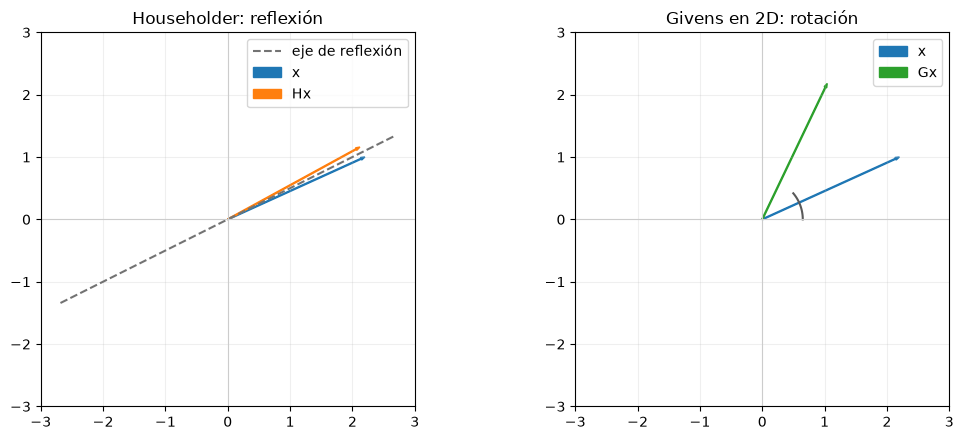

||x||, ||Hx||, ||Gx|| = 2.4166091947189146 2.4166091947189146 2.4166091947189146
det(H) = -0.9999999999999999 det(G) = 1.0


In [19]:
def dibujar_vector(ax, v, color, etiqueta):
    ax.arrow(0, 0, v[0], v[1], width=0.015, length_includes_head=True,
             color=color, label=etiqueta)

x_geo = np.array([2.2, 1.0])

# Householder: reflexión respecto de la recta perpendicular al vector normal n.
n_normal = np.array([1.0, -2.0])
n_normal /= np.linalg.norm(n_normal)
H = np.eye(2) - 2 * np.outer(n_normal, n_normal)
x_reflejado = H @ x_geo

# Rotación antihoraria de 40 grados.
theta = np.deg2rad(40)
G = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
x_rotado = G @ x_geo

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

direccion_espejo = np.array([-n_normal[1], n_normal[0]])
t = np.linspace(-3, 3, 2)
axes[0].plot(t * direccion_espejo[0], t * direccion_espejo[1],
             color="0.45", linestyle="--", label="eje de reflexión")
dibujar_vector(axes[0], x_geo, "tab:blue", "x")
dibujar_vector(axes[0], x_reflejado, "tab:orange", "Hx")
axes[0].set_title("Householder: reflexión")

dibujar_vector(axes[1], x_geo, "tab:blue", "x")
dibujar_vector(axes[1], x_rotado, "tab:green", "Gx")
arco = np.linspace(0, theta, 60)
axes[1].plot(0.65 * np.cos(arco), 0.65 * np.sin(arco), color="0.35")
axes[1].set_title("Givens en 2D: rotación")

for ax in axes:
    ax.axhline(0, color="0.8", linewidth=0.8)
    ax.axvline(0, color="0.8", linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()

print("||x||, ||Hx||, ||Gx|| =", np.linalg.norm(x_geo),
      np.linalg.norm(x_reflejado), np.linalg.norm(x_rotado))
print("det(H) =", np.linalg.det(H), "det(G) =", np.linalg.det(G))

In [20]:
# Los productos internos y los ángulos también se preservan.
y_geo = np.array([-0.5, 2.0])
for nombre, Q_geo in [("Householder", H), ("Givens", G)]:
    print(nombre)
    print("  error de norma =", abs(np.linalg.norm(Q_geo @ x_geo) - np.linalg.norm(x_geo)))
    print("  error de producto interno =",
          abs((Q_geo @ x_geo) @ (Q_geo @ y_geo) - x_geo @ y_geo))
    print("  error de ortogonalidad =", np.linalg.norm(Q_geo.T @ Q_geo - np.eye(2)))

Householder
  error de norma = 0.0
  error de producto interno = 0.0
  error de ortogonalidad = 3.4239537274495635e-16
Givens
  error de norma = 0.0
  error de producto interno = 0.0
  error de ortogonalidad = 1.5711325783642226e-16


### QR como cambio rígido de coordenadas

En \(Q^TA=R\), la multiplicación por \(Q^T\) aplica el mismo movimiento rígido
a todas las columnas de \(A\). No deforma la nube de vectores: cambia el sistema
de coordenadas hasta hacer triangular la matriz.

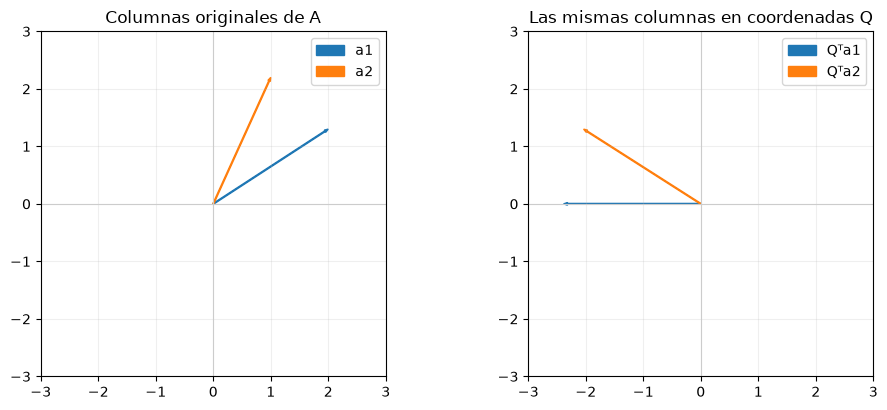

QᵀA =
 [[-2.385372 -2.037418]
 [-0.        1.299588]]
R   =
 [[-2.385372 -2.037418]
 [ 0.        1.299588]]


In [21]:
A_geo = np.array([[2.0, 1.0], [1.3, 2.2]])
Q_geo, R_geo = np.linalg.qr(A_geo)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for j, color in enumerate(["tab:blue", "tab:orange"]):
    dibujar_vector(axes[0], A_geo[:, j], color, f"a{j+1}")
    dibujar_vector(axes[1], R_geo[:, j], color, f"Qᵀa{j+1}")
axes[0].set_title("Columnas originales de A")
axes[1].set_title("Las mismas columnas en coordenadas Q")
for ax in axes:
    ax.axhline(0, color="0.8", linewidth=0.8)
    ax.axvline(0, color="0.8", linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()

print("QᵀA =\n", Q_geo.T @ A_geo)
print("R   =\n", R_geo)

### Actividad geométrica

1. Varíe el ángulo de Givens y observe qué ángulo anula la segunda componente.
2. Cambie la normal de Householder y describa el eje de reflexión resultante.
3. Verifique que el área orientada cambia de signo con \(H\), pero no con \(G\).
4. Explique por qué una composición de reflexiones puede producir una rotación.

## 8. QR mediante reflexiones de Householder

Las transformaciones ortogonales preservan la norma 2. Householder anula toda
la cola de una columna con una reflexión.

In [22]:
def qr_householder(A):
    R = np.array(A, dtype=float, copy=True)
    m, n = R.shape
    Q = np.eye(m)
    for k in range(min(n, m - 1)):
        x = R[k:, k]
        norma = np.linalg.norm(x)
        if norma == 0:
            continue
        alpha = -math.copysign(norma, x[0])
        v = x.copy()
        v[0] -= alpha
        v /= np.linalg.norm(v)
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])
        Q[:, k:] -= 2.0 * np.outer(Q[:, k:] @ v, v)
    R[np.abs(R) < 1e-14] = 0.0
    return Q, R

In [23]:
A_qr = np.array([[63., 41., -88.], [42., 60., 51.],
                 [0., -28., 56.], [126., 82., -71.]])
Q_h, R_h = qr_householder(A_qr)
print("R de Householder =\n", R_h)
print("Error de factorización =", verificar_factorizacion(A_qr, Q_h @ R_h))
print("Error de ortogonalidad =", np.linalg.norm(Q_h.T @ Q_h - np.eye(Q_h.shape[0])))
assert np.allclose(A_qr, Q_h @ R_h)
assert np.allclose(Q_h.T @ Q_h, np.eye(Q_h.shape[0]))

R de Householder =
 [[-147. -105.   84.]
 [   0.  -42.  -21.]
 [   0.    0. -105.]
 [   0.    0.    0.]]
Error de factorización = 4.542117283655108e-16
Error de ortogonalidad = 1.0194713193506138e-15


## 9. QR mediante rotaciones de Givens

Givens anula una entrada por rotación y modifica solo dos filas. Esto resulta
útil cuando importa conservar ceros o actualizar localmente una matriz.

In [24]:
def qr_givens(A):
    R = np.array(A, dtype=float, copy=True)
    m, n = R.shape
    Q = np.eye(m)
    for j in range(min(m, n)):
        for i in range(m - 1, j, -1):
            a, b = R[j, j], R[i, j]
            if b == 0:
                continue
            gamma = math.hypot(a, b)
            c, s = a / gamma, b / gamma
            fila_j = c * R[j, :] + s * R[i, :]
            fila_i = -s * R[j, :] + c * R[i, :]
            R[j, :], R[i, :] = fila_j, fila_i
            col_j = c * Q[:, j] + s * Q[:, i]
            col_i = -s * Q[:, j] + c * Q[:, i]
            Q[:, j], Q[:, i] = col_j, col_i
    R[np.abs(R) < 1e-14] = 0.0
    return Q, R

In [25]:
Q_g, R_g = qr_givens(A_qr)
print("R de Givens =\n", R_g)
print("Error de factorización =", verificar_factorizacion(A_qr, Q_g @ R_g))
print("Error de ortogonalidad =", np.linalg.norm(Q_g.T @ Q_g - np.eye(Q_g.shape[0])))
assert np.allclose(A_qr, Q_g @ R_g)
assert np.allclose(Q_g.T @ Q_g, np.eye(Q_g.shape[0]))

R de Givens =
 [[147. 105. -84.]
 [  0.  42.  21.]
 [  0.   0. 105.]
 [  0.   0.   0.]]
Error de factorización = 1.0244166502502226e-16
Error de ortogonalidad = 3.421475745986799e-16


### Actividad 5

1. Compare los signos de las diagonales de las dos matrices \(R\).
2. Compruebe que cambiar el signo de una columna de \(Q\) y la fila
   correspondiente de \(R\) no altera \(QR\).
3. Cuente cuántas reflexiones y rotaciones requiere una matriz \(m\times n\).

## 10. Mínimos cuadrados: una aplicación económica

Ajustaremos una función consumo
\[
C_t=\alpha+\beta Y_t+\varepsilon_t
\]
sin formar las ecuaciones normales, pues estas cuadran aproximadamente el
número de condición.

In [26]:
ingreso = np.array([100., 120., 140., 160., 180., 200., 220., 240.])
consumo = np.array([92., 103., 115., 126., 139., 151., 163., 174.])
X = np.column_stack([np.ones_like(ingreso), ingreso])
Q, R = qr_householder(X)
c = Q.T @ consumo
theta_qr = sustitucion_atras(R[:2, :2], c[:2])
theta_ref, *_ = np.linalg.lstsq(X, consumo, rcond=None)
residuo = consumo - X @ theta_qr
print("alpha, beta por QR =", theta_qr)
print("Referencia NumPy   =", theta_ref)
print("||residuo||₂       =", np.linalg.norm(residuo))
assert np.allclose(theta_qr, theta_ref)

alpha, beta por QR = [32.190476  0.592262]
Referencia NumPy   = [32.190476  0.592262]
||residuo||₂       = 1.3671311638052908


### Actividad 6

1. Interprete \(\widehat\alpha\) y \(\widehat\beta\).
2. Agregue una columna \(Y_t^2\) y compare el condicionamiento de \(X\) y
   \(X^TX\).
3. Centre y escale el ingreso. ¿Cambia el ajuste? ¿Cambia el condicionamiento?

## 11. Jacobi, Gauss–Seidel y SOR

La función devuelve la trayectoria del residuo escalado y del cambio relativo.
El algoritmo nunca interpreta un máximo de iteraciones como convergencia.

In [27]:
def iteracion_estacionaria(A, b, metodo="jacobi", omega=1.0, x0=None,
                           tol=1e-10, max_iter=10_000):
    A, b = np.asarray(A, dtype=float), np.asarray(b, dtype=float)
    n = b.size
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float, copy=True)
    if np.any(np.diag(A) == 0):
        raise np.linalg.LinAlgError("La diagonal contiene ceros")
    if metodo not in {"jacobi", "gauss-seidel", "sor"}:
        raise ValueError("Método desconocido")
    historial = []
    for k in range(1, max_iter + 1):
        anterior = x.copy()
        if metodo == "jacobi":
            x = (b - (A - np.diag(np.diag(A))) @ anterior) / np.diag(A)
        else:
            for i in range(n):
                propuesta = (b[i] - A[i, :i] @ x[:i]
                             - A[i, i + 1:] @ anterior[i + 1:]) / A[i, i]
                peso = 1.0 if metodo == "gauss-seidel" else omega
                x[i] = (1.0 - peso) * anterior[i] + peso * propuesta
        residuo = norma_relativa_residuo(A, x, b)
        cambio = np.linalg.norm(x - anterior) / (1.0 + np.linalg.norm(x))
        historial.append((residuo, cambio))
        if residuo <= tol and cambio <= tol:
            return x, np.array(historial), "convergencia"
    return x, np.array(historial), "máximo de iteraciones"

In [28]:
A_it = np.array([[4., -1., 0.], [-1., 4., -1.], [0., -1., 3.]])
b_it = np.array([15., 10., 10.])
x_exacta = np.array([5., 5., 5.])
for metodo, omega in [("jacobi", 1.0), ("gauss-seidel", 1.0), ("sor", 1.04)]:
    x, hist, salida = iteracion_estacionaria(
        A_it, b_it, metodo=metodo, omega=omega, tol=1e-12)
    print(f"{metodo:14s} iter={len(hist):3d} salida={salida:22s}",
          f"error={error_relativo(x, x_exacta):.3e}")

jacobi         iter= 30 salida=convergencia           error=2.890e-13
gauss-seidel   iter= 16 salida=convergencia           error=1.042e-13
sor            iter= 11 salida=convergencia           error=9.865e-15


In [29]:
def matrices_iterativas(A, omega=1.0):
    D, L, U = np.diag(np.diag(A)), np.tril(A, -1), np.triu(A, 1)
    T_j = -np.linalg.solve(D, L + U)
    T_gs = -np.linalg.solve(D + L, U)
    T_sor = np.linalg.solve(D + omega * L, (1 - omega) * D - omega * U)
    return T_j, T_gs, T_sor

def radio_espectral(T):
    return np.max(np.abs(np.linalg.eigvals(T)))

T_j, T_gs, T_sor = matrices_iterativas(A_it, omega=1.04)
print("rho(Jacobi)       =", radio_espectral(T_j))
print("rho(Gauss-Seidel) =", radio_espectral(T_gs))
print("rho(SOR, 1.04)    =", radio_espectral(T_sor))

rho(Jacobi)       = 0.3818813079129867
rho(Gauss-Seidel) = 0.14583333333333331
rho(SOR, 1.04)    = 0.04000000000000007


In [30]:
omegas = np.linspace(0.05, 1.95, 191)
radios = np.array([radio_espectral(matrices_iterativas(A_it, omega=w)[2])
                   for w in omegas])
i_opt = np.argmin(radios)
print("Mejor omega en la malla =", omegas[i_opt])
print("Radio espectral mínimo  =", radios[i_opt])
for w in [0.5, 1.0, omegas[i_opt], 1.5, 1.95]:
    x, hist, salida = iteracion_estacionaria(
        A_it, b_it, metodo="sor", omega=float(w), tol=1e-10, max_iter=5000)
    print(f"omega={w:5.2f}: iter={len(hist):4d}, {salida}")

Mejor omega en la malla = 1.04
Radio espectral mínimo  = 0.04000000000000007
omega= 0.50: iter=  53, convergencia
omega= 1.00: iter=  14, convergencia
omega= 1.04: iter=  10, convergencia
omega= 1.50: iter=  35, convergencia
omega= 1.95: iter= 453, convergencia


### Actividad 7

1. Explique la relación entre radio espectral e iteraciones observadas.
2. Pruebe \(\omega=2.05\) y documente el diagnóstico.
3. Cambie el orden de las variables. ¿Se modifica Gauss–Seidel?
4. Construya una matriz para la que Jacobi diverja.

## 12. Modelo de Leontief: solución y sensibilidad

Con matriz de coeficientes técnicos \(C\) y demanda final \(d\), la producción
bruta satisface
\[
x=Cx+d,\qquad (I-C)x=d.
\]
Ahora podemos analizar tanto la solución como su sensibilidad.

In [31]:
C = np.array([[0.20, 0.10, 0.00], [0.15, 0.25, 0.10], [0.05, 0.10, 0.20]])
d = np.array([100., 80., 60.])
A_leontief = np.eye(3) - C
x = np.linalg.solve(A_leontief, d)
print("Producción requerida =", x)
print("cond₂(I-C)           =", np.linalg.cond(A_leontief))
print("Residuo relativo     =", norma_relativa_residuo(A_leontief, x, d))
print("Radio espectral de C =", radio_espectral(C))
assert radio_espectral(C) < 1

Producción requerida = [143.634385 149.075082 102.611534]
cond₂(I-C)           = 1.5322059693666883
Residuo relativo     = 3.456290216108771e-17
Radio espectral de C = 0.3929761694307613


In [32]:
d_pert = d.copy()
d_pert[0] *= 1.01
x_pert = np.linalg.solve(A_leontief, d_pert)
pert_d = np.linalg.norm(d_pert - d) / np.linalg.norm(d)
pert_x = np.linalg.norm(x_pert - x) / np.linalg.norm(x)
print("Cambio relativo de demanda    =", pert_d)
print("Cambio relativo de producción =", pert_x)
print("Amplificación observada        =", pert_x / pert_d)
print("Cota por condicionamiento      =", np.linalg.cond(A_leontief))

Cambio relativo de demanda    = 0.007071067811865475
Cambio relativo de producción = 0.005702134783434292
Amplificación observada        = 0.8064036345212147
Cota por condicionamiento      = 1.5322059693666883


### Actividad 8: escenario económico integrado

1. Aumente en 5% la demanda final del segundo sector.
2. Resuelva cinco escenarios reutilizando una factorización LU.
3. Perturbe un coeficiente técnico y distinga este cambio de una perturbación
   del lado derecho.
4. Construya una matriz \(C\) con radio espectral cercano a uno. Compare
   multiplicadores, condicionamiento e iteraciones.
5. Redacte una conclusión económica y una advertencia numérica.

In [33]:
# Espacio de trabajo para la Actividad 8.
# Escriba aquí sus escenarios, cálculos y tablas de resultados.

## 13. Síntesis y entrega

Entregue el cuaderno ejecutado con:

1. respuestas breves a las preguntas conceptuales;
2. resultados de al menos seis actividades;
3. una tabla que compare método, estructura exigida, costo y diagnóstico;
4. el escenario de Leontief con interpretación económica;
5. una conclusión de no más de 200 palabras.

### Lista de verificación

- [ ] No se formaron inversas para resolver sistemas.
- [ ] Toda solución incluye residuo escalado.
- [ ] Toda factorización incluye error de reconstrucción.
- [ ] Toda iteración informa tolerancia, número de pasos y razón de salida.
- [ ] Las conclusiones distinguen condicionamiento y estabilidad.

In [34]:
print("Laboratorio ejecutado hasta el final.")
print("Complete las actividades y respuestas antes de entregar.")

Laboratorio ejecutado hasta el final.
Complete las actividades y respuestas antes de entregar.
